# Техническая очистка


Цель данного ноутбука - проверить набор данных на дублирующиеся значения, пропуски и логические несоответствия, а затем привести признаки к форматам, пригодным для дальнейшего анализа.


## Загрузка библиотек и установка настроек

In [1]:
import pandas as pd

import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("viridis")
pd.set_option("display.float_format", "{:.4f}".format)


## Загрузка набора данных

In [2]:
listings = pd.read_csv("../data/raw/listings.csv")


## Проверка дублирующихся значений

#### Проверка полностью дублирующихся объектов

In [3]:
listings.duplicated().sum().item()


0

Полных дубликатов в таблице не обнаружено

#### Проверка дублирующихся id объектов

In [4]:
listings["id"].nunique() / listings["id"].shape[0]


1.0

Поле `id` остаётся уникальным для каждого объявления

#### Проверка дублирующихся хостов

In [5]:
listings["host_id"].nunique() / listings.shape[0]


0.6160589060308556

Доля уникальных `host_id` составляет около *61.6%*, поэтому часть хостов размещает несколько объявлений. Такие дубликаты являются естественным и не считаются ошибкой.


## Проверка пропусков и NULL значений

<Axes: >

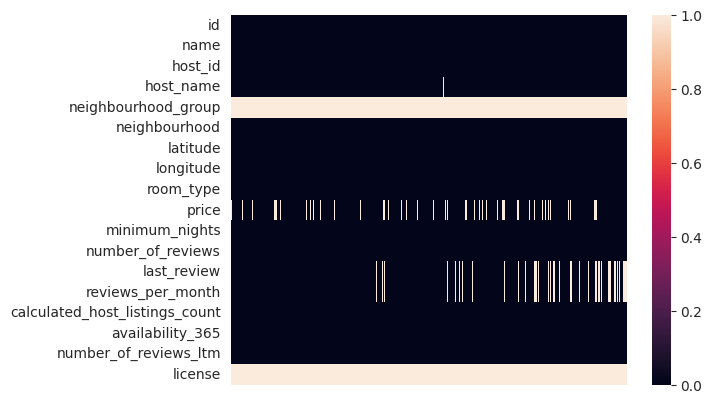

In [6]:
sns.heatmap(listings.isnull().T, xticklabels=False)


In [7]:
listings.isna().mean().sort_values(ascending=False)


license                          1.0000
neighbourhood_group              1.0000
price                            0.1104
reviews_per_month                0.0852
last_review                      0.0852
host_name                        0.0011
name                             0.0000
id                               0.0000
neighbourhood                    0.0000
host_id                          0.0000
room_type                        0.0000
longitude                        0.0000
latitude                         0.0000
number_of_reviews                0.0000
minimum_nights                   0.0000
calculated_host_listings_count   0.0000
availability_365                 0.0000
number_of_reviews_ltm            0.0000
dtype: float64

Поле `price` содержит пропуски примерно у *11.0%* объектов и на этом этапе сохраняется без заполнения с целью последующего анализа. 
 
Поле `host_name` содержит пропуски у *0.11%* объектов. В масштабе всего объёма данных нельзя делать выводы на основе присутствия/отсутсвия имени.   


### Проверка того, что `last_review` и `reviews_per_month` пропущены одновременно

In [8]:
print((listings["last_review"].isna() == listings["reviews_per_month"].isna()).mean())


1.0


Признаки `last_review` и `reviews_per_month` пропущены одновременно во всех случаях, что логически согласуется с объявлениями без отзывов.  


### Проверка того, что `neighbourhood_group` и `license` полностью пусты

In [9]:
print(listings["neighbourhood_group"].isna().mean())
print(listings["license"].isna().mean())


1.0
1.0


Столбцы `neighbourhood_group` и `license` отсутствуют полностью, поэтому не несут аналитической ценности и будут удалены на этапе очистки.

## Уникальность значений

In [10]:
listings.nunique()


id                                2852
name                              2842
host_id                           1757
host_name                          987
neighbourhood_group                  0
neighbourhood                        8
latitude                          2571
longitude                         2579
room_type                            4
price                              470
minimum_nights                      27
number_of_reviews                  510
last_review                        490
reviews_per_month                  645
calculated_host_listings_count      23
availability_365                   360
number_of_reviews_ltm               99
license                              0
dtype: int64

In [11]:
listings["neighbourhood"].unique()


array([28806, 28804, 28805, 28803, 28801, 28704, 28732, 28715])

Признак `neighbourhood` принимает только *8* значений и фактически описывает ограниченный набор ZIP-кодов. Следовательно, далее его корректно интерпретировать как категориальный, а не количественный признак.

In [12]:
listings["room_type"].unique()


<ArrowStringArray>
['Entire home/apt', 'Private room', 'Shared room', 'Hotel room']
Length: 4, dtype: str

Поле `room_type` также содержит фиксированный набор категорий.  
Остальные признаки сохраняют разумное число уникальных наблюдений.


## Проверка согласованности данных

In [13]:
print(
    (
        (listings["number_of_reviews"] == 0)
        == (listings["last_review"].isna() & listings["reviews_per_month"].isna())
    ).mean()
)


1.0


Объявления без отзывов действительно имеют нулевое значение `number_of_reviews` и одновременно пустые `last_review` и `reviews_per_month`.

In [14]:
NOT_NEGATIVE_COLUMNS = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "number_of_reviews_ltm",
]

for column in NOT_NEGATIVE_COLUMNS:
    print(
        f"Column: {column}, number of negative values: {(listings[column] < 0).sum()}"
    )


Column: price, number of negative values: 0
Column: minimum_nights, number of negative values: 0
Column: number_of_reviews, number of negative values: 0
Column: reviews_per_month, number of negative values: 0
Column: calculated_host_listings_count, number of negative values: 0
Column: availability_365, number of negative values: 0
Column: number_of_reviews_ltm, number of negative values: 0


Во всех числовых признаках, где отрицательные значения недопустимы, таких значений не обнаружено

In [15]:
print(
    (
        listings["calculated_host_listings_count"]
        == listings.groupby("host_id")["id"].transform("count")
    ).all()
)


True


Поле `calculated_host_listings_count` полностью совпадает с фактическим числом объявлений у каждого хоста, что подтверждает корректность данных.


## Преобразования признаков


### Преобразование `last_review` из `str` в тип `date`

In [16]:
listings["last_review"] = pd.to_datetime(listings["last_review"], format="%Y-%m-%d")


### Преобразование `neighbourhood` из `int64` в тип `category`

In [17]:
listings["neighbourhood"] = listings["neighbourhood"].astype("category")


### Удаление пустых столбцов `neighbourhood_group`, `license`

In [18]:
listings.drop(columns=["neighbourhood_group", "license"], inplace=True)


После преобразований набор данных становится более пригодным для дальнейшего анализа. Поле `last_review` приведено к календарному типу, `neighbourhood` переведено в категориальный формат, а полностью пустые столбцы удалены из рабочей таблицы.


## Сохранение изменений

In [19]:
listings.to_parquet("../data/processed/listings_clean.parquet", index=False)
